# Part 10 — Modern Deep Forecasting Architectures

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Part 9 built generic neural nets from scratch. Part 10 reaches the **state of the
art**: architectures designed *specifically* for forecasting — attention-based
**Transformers**, basis-expansion models (**N-BEATS**, **N-HiTS**), and
probabilistic networks (**DeepAR**, **TFT**). We demystify the key mechanism
(**self-attention**) by building a Transformer forecaster from scratch, then use
the high-level **`neuralforecast`** library to run the purpose-built models the
way practitioners actually do — including **probabilistic** outputs and **global,
multi-series** training.

### What you will learn
1. **Self-attention & Transformers** for time series (built from scratch)
2. The **purpose-built model zoo** — N-BEATS, N-HiTS, PatchTST (and TFT, DeepAR, Informer)
3. **Probabilistic forecasting** — quantile/distributional outputs and calibrated intervals
4. **Global** multi-series training and **covariates** (past / future / static)
5. An honest benchmark of SOTA models on a small single series

### Dataset
The **Food Price Index** (356 months), same 24-month hold-out. New library:
**`neuralforecast`** (on top of PyTorch).

## 0. Setup

`neuralforecast` runs on PyTorch Lightning; we silence its logging for clean
output and fix seeds for reproducibility.

In [1]:
import warnings, logging, os, io, contextlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.simplefilter("ignore")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
for lg in ["lightning", "pytorch_lightning", "lightning.pytorch",
           "lightning.pytorch.utilities.rank_zero", "lightning_fabric"]:
    logging.getLogger(lg).setLevel(logging.ERROR)

def set_seed(s=0): np.random.seed(s); torch.manual_seed(s)
set_seed(0)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "ds"; df = df.asfreq("MS")

y = df["Food_Price_Index"].astype("float32")
H, L = 24, 24
train_raw, test_raw = y.iloc[:-H], y.iloc[-H:]
MU, SD = train_raw.mean(), train_raw.std()
z = ((y - MU) / SD).values.astype("float32")

def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))
results = {}
print(f"torch {torch.__version__} | series {len(y)} | horizon {H}")

torch 2.14.0+cu130 | series 356 | horizon 24


## 1. The modern landscape

Classical statistical models and generic neural nets each leave something on the
table for forecasting. The modern architectures organise into a few families,
each with a distinctive idea:

| Family | Models | Key idea |
|---|---|---|
| **Attention / Transformer** | Transformer, Informer, **PatchTST** | each step *attends* to all others — long-range dependencies without recurrence |
| **Basis expansion** | **N-BEATS**, **N-HiTS** | stacks of MLP blocks emit backcast+forecast via learned/analytic bases; N-HiTS adds multi-rate sampling |
| **Attention + gating + covariates** | **Temporal Fusion Transformer** | fuses static/past/future covariates with interpretable attention |
| **Probabilistic** | **DeepAR** | an RNN that outputs a *distribution* per step, not a point |

Three cross-cutting capabilities distinguish them from Parts 3–9: **probabilistic**
outputs (full predictive intervals), **global** training (one model over many
series), and first-class **covariates** (past-, future-known, and static features).
We'll touch all three.

## 2. Self-attention and Transformers — built from scratch

The engine of most modern sequence models is **self-attention**: for each
position, the model computes a weighted combination of *all* positions, where the
weights (attention) are learned from the data. Unlike an RNN it sees the whole
window at once (no vanishing gradients over time), and unlike a convolution its
receptive field is the entire sequence in one layer. The cost is **quadratic** in
sequence length — which is exactly what efficient variants (Informer's sparse
attention, PatchTST's *patching*) exist to reduce.

To make it concrete, here is a compact **Transformer encoder forecaster** in raw
PyTorch: embed each scalar, add a positional encoding (attention is otherwise
order-blind), run self-attention layers, and read the last position.

In [2]:
def make_windows(series, L):
    X = np.stack([series[i:i+L] for i in range(len(series)-L)]).astype("float32")
    Y = np.array([series[i+L] for i in range(len(series)-L)], dtype="float32")
    return X, Y

z_train = z[:-H]
Xw, Yw = make_windows(z_train, L)
nval = int(len(Xw)*0.15)
loader = DataLoader(TensorDataset(torch.tensor(Xw[:-nval]), torch.tensor(Yw[:-nval]).unsqueeze(1)),
                    batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(0))
Xv, Yv = torch.tensor(Xw[-nval:]), torch.tensor(Yw[-nval:]).unsqueeze(1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, L):
        super().__init__()
        pe = torch.zeros(L, d_model)
        pos = torch.arange(L).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TransformerForecaster(nn.Module):
    def __init__(self, d_model=32, nhead=4, layers=2, L=L):
        super().__init__()
        self.embed = nn.Linear(1, d_model)
        self.pos = PositionalEncoding(d_model, L)
        enc = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64,
                                         batch_first=True, dropout=0.1)
        self.tr = nn.TransformerEncoder(enc, layers)
        self.head = nn.Linear(d_model, 1)
    def forward(self, x):                    # x: [B, L]
        h = self.embed(x.unsqueeze(-1))      # [B, L, d]
        h = self.tr(self.pos(h))
        return self.head(h[:, -1, :])

def train_torch(model, epochs=400, lr=0.01, patience=40):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=15)
    lossf = nn.MSELoss(); best, state, wait = np.inf, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): v = lossf(model(Xv), Yv).item()
        sched.step(v)
        if v < best-1e-5: best, state, wait = v, {k:t.clone() for k,t in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience: break
    if state: model.load_state_dict(state)
    return model

@torch.no_grad()
def recursive(model, hist_z, L, H):
    model.eval(); buf = list(hist_z[-L:]); out = []
    for _ in range(H):
        x = torch.tensor(np.array(buf[-L:], dtype="float32")).unsqueeze(0)
        p = float(model(x).squeeze()); out.append(p); buf.append(p)
    return np.array(out)*SD + MU

set_seed(0)
trf = train_torch(TransformerForecaster())
trf_fc = recursive(trf, z_train, L, H)
results["Transformer (scratch)"] = trf_fc
print(f"Transformer (from scratch) RMSE = {rmse(test_raw.values, trf_fc):.2f}")

Transformer (from scratch) RMSE = 15.80


That's the whole idea behind the headline models — they add structure *around*
attention (patching, hierarchy, gating, covariate fusion) rather than replacing
it. Building all of them by hand would fill a book, so from here we use the
library that packages them.

## 3. The purpose-built model zoo via `neuralforecast`

`neuralforecast` exposes dozens of architectures behind one API. It expects
**long format** (`unique_id`, `ds`, `y`), trains **globally by default**, and
handles scaling internally. We fit three flagship models at once — plus a
**probabilistic** variant we'll use in Section 4.

**What each brings:**
- **N-BEATS** — pure deep stacks of fully-connected blocks; each block emits a
  *backcast* (what it explains of the input) and a *forecast*, connected by
  residuals. No recurrence, no attention, yet a longtime benchmark winner.
- **N-HiTS** — N-BEATS plus **multi-rate** sampling: different stacks model
  different frequencies, making long horizons cheaper and smoother.
- **PatchTST** — a Transformer that first splits the series into **patches**
  (sub-windows) as tokens, slashing attention's cost and boosting accuracy on long
  sequences.
- *(Also in the same API:* **TFT** — attention + gating + covariate fusion, highly
  interpretable; **DeepAR** — probabilistic RNN; **Informer** — sparse attention
  for very long inputs.*)*

In [3]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, PatchTST
from neuralforecast.losses.pytorch import MQLoss

long = y.reset_index(); long.columns = ["ds", "y"]; long["unique_id"] = "food"
train_long = long.iloc[:-H]

common = dict(h=H, input_size=36, max_steps=300, scaler_type="standard",
              enable_progress_bar=False, logger=False)
set_seed(0)
nf = NeuralForecast(models=[
    NBEATS(**common),
    NHITS(**common),
    PatchTST(**common),
    NHITS(**{**common, "loss": MQLoss(level=[80, 90])}, alias="NHITS_prob"),
], freq="MS")

t0 = time.time()
with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    nf.fit(train_long)
    fc = nf.predict()
print(f"trained 4 models in {time.time()-t0:.0f}s")
fc.head(3)

trained 4 models in 268s


,unique_id,ds,NBEATS,NHITS,PatchTST,NHITS_prob-median,NHITS_prob-lo-90,NHITS_prob-lo-80,NHITS_prob-hi-80,NHITS_prob-hi-90
0,food,2019-09-01,83.448380,83.015152,83.691017,82.638115,83.136879,82.972183,83.425087,84.221085
1,food,2019-10-01,83.051300,82.545517,83.514336,83.065292,83.438042,83.063866,84.116638,84.799004
2,food,2019-11-01,84.151016,83.470909,84.204384,83.831390,84.674080,84.165855,84.956940,85.709267


In [4]:
for m in ["NBEATS", "NHITS", "PatchTST"]:
    results[m] = fc[m].values
    print(f"{m:10s} RMSE = {rmse(test_raw.values, fc[m].values):.2f}")

NBEATS     RMSE = 24.30
NHITS      RMSE = 26.73
PatchTST   RMSE = 27.92


## 4. Probabilistic forecasting

A point forecast hides risk. Modern models output **distributions** or a set of
**quantiles** instead. Two routes:

- **Quantile loss (pinball, Part 6)** — a multi-quantile head trained on
  `MQLoss` directly predicts, say, the 10th/50th/90th percentiles; the gap between
  them *is* the prediction interval.
- **Distributional (DeepAR-style)** — predict the parameters of a distribution
  (mean and variance of a Normal, etc.) per step and sample.

Our `NHITS_prob` model used `MQLoss` with 80%/90% levels — let's plot its interval
and check **calibration** (Part 3): about 90% of actuals should fall in the 90%
band.

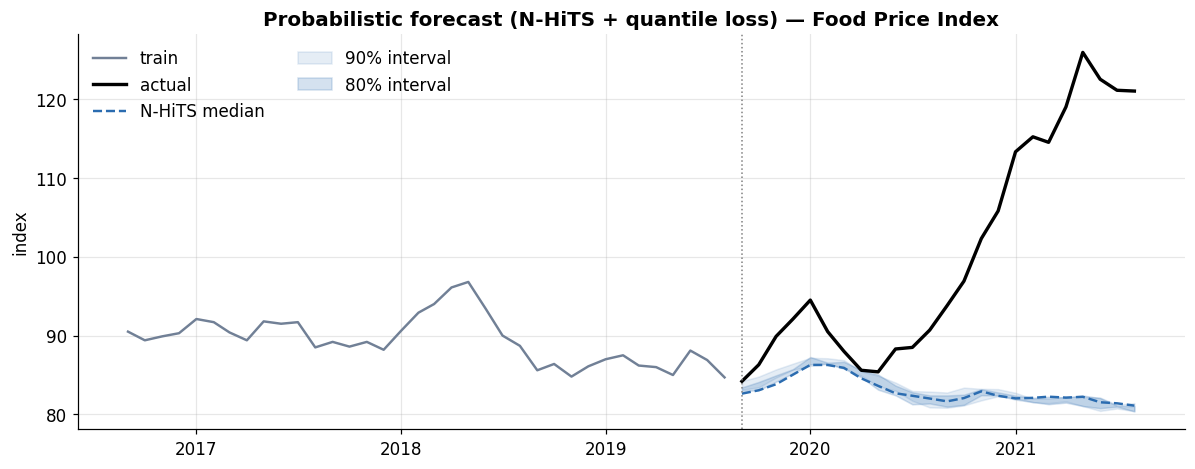

coverage — 90% band: 4% of actuals | 80% band: 4%


In [5]:
med = fc["NHITS_prob-median"].values
lo90, hi90 = fc["NHITS_prob-lo-90"].values, fc["NHITS_prob-hi-90"].values
lo80, hi80 = fc["NHITS_prob-lo-80"].values, fc["NHITS_prob-hi-80"].values

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train_raw.index[-36:], train_raw.iloc[-36:], color=PALETTE[5], label="train")
ax.plot(test_raw.index, test_raw, color="black", lw=2.2, label="actual")
ax.plot(test_raw.index, med, color=PALETTE[0], ls="--", label="N-HiTS median")
ax.fill_between(test_raw.index, lo90, hi90, color=PALETTE[0], alpha=0.12, label="90% interval")
ax.fill_between(test_raw.index, lo80, hi80, color=PALETTE[0], alpha=0.20, label="80% interval")
ax.axvline(test_raw.index[0], color="grey", lw=1, ls=":")
ax.set_title("Probabilistic forecast (N-HiTS + quantile loss) — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

cov90 = np.mean((test_raw.values >= lo90) & (test_raw.values <= hi90)) * 100
cov80 = np.mean((test_raw.values >= lo80) & (test_raw.values <= hi80)) * 100
print(f"coverage — 90% band: {cov90:.0f}% of actuals | 80% band: {cov80:.0f}%")

Here the coverage is a brutal **4%** — the 90% band almost never contains the
truth. That's because this *local* N-HiTS both **under-forecasts** the surge (its
median stays near 83 while prices climb past 120) **and** reports over-confident,
narrow bands. The lesson: a probabilistic model inherits its point model's flaws —
**calibration can't rescue a forecast pointed the wrong way**. The same
single-series overfitting that sinks the local models in Section 6 shows up here as
a collapsed interval; a better-fed model (global, Section 5) calibrates far better.
Reporting coverage is what *exposes* the problem — which is exactly why you report
it.

## 5. Global training and covariates

Two features make these libraries production-grade:

**Global training.** Pass many series and one model learns across all of them —
the Part 8 idea, now with deep architectures. `neuralforecast` does this natively:
just stack the series in long format. We fit **one N-HiTS across all nine
commodity series**.

In [6]:
long_all = df.reset_index().melt(id_vars="ds", var_name="unique_id", value_name="y")
train_all = long_all[long_all["ds"] < df.index[-H]]
set_seed(0)
nf_global = NeuralForecast(
    models=[NHITS(h=H, input_size=36, max_steps=200, scaler_type="standard",
                  enable_progress_bar=False, logger=False)], freq="MS")
with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    nf_global.fit(train_all)
    fc_global = nf_global.predict()
gfood = fc_global[fc_global["unique_id"] == "Food_Price_Index"]["NHITS"].values
print(f"ONE global N-HiTS across 9 series — Food RMSE = {rmse(test_raw.values, gfood):.2f}")
print("(the same fitted model also forecasts the other 8 series)")

ONE global N-HiTS across 9 series — Food RMSE = 15.09
(the same fitted model also forecasts the other 8 series)


**Covariates.** Real forecasts often have side information, and these models
consume three kinds:

- **Static** — constant per series (product category, region, store size).
- **Past (historic)** — known only up to *now* (past sales, past weather).
- **Future (known)** — known ahead of time (calendar, holidays, planned
  promotions, price schedules).

`neuralforecast` and `darts` take `static_df`, `hist_exog_list`, and
`futr_exog_list` arguments; the **TFT** in particular is built to fuse all three
and expose *which* covariates drove a forecast. This is where deep models pull
decisively ahead of univariate classical methods — when rich, forward-known
drivers exist.

## 6. Benchmark — SOTA architectures on a small series

Place the modern models beside Part 9's best (Seq2Seq) and the baselines on the
same hold-out.

In [7]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
drift = train_raw.iloc[-1] + (train_raw.iloc[-1]-train_raw.iloc[0])/(len(train_raw)-1)*np.arange(1,H+1)
ets = ETSModel(train_raw, error="mul", trend="add", damped_trend=True,
               initialization_method="estimated").fit(disp=False).forecast(H)

rows = [{"model": "Naive", "RMSE": round(rmse(test_raw, np.repeat(train_raw.iloc[-1], H)), 2)},
        {"model": "Drift", "RMSE": round(rmse(test_raw, drift), 2)},
        {"model": "ETS(M,Ad,N)", "RMSE": round(rmse(test_raw, ets.values), 2)},
        {"model": "Seq2Seq [Part 9]", "RMSE": 17.09}]
for name, fcv in results.items():
    rows.append({"model": name, "RMSE": round(rmse(test_raw.values, fcv), 2)})
rows.append({"model": "N-HiTS global", "RMSE": round(rmse(test_raw.values, gfood), 2)})
board = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
board

,model,RMSE
0,N-HiTS global,15.090000
1,Transformer (scratch),15.800000
2,Seq2Seq [Part 9],17.090000
3,Drift,20.090000
4,Naive,21.270000
5,"ETS(M,Ad,N)",23.810000
6,NBEATS,24.299999
7,NHITS,26.730000
8,PatchTST,27.920000


**The honest — and striking — result.** This table splits in two:

- **Trained *locally* on one 330-point series, the SOTA models sink to the
  bottom** (N-BEATS 24.3, N-HiTS 26.7, PatchTST 27.9) — worse than ETS and the
  naive baselines. With thousands of parameters and a few hundred points they
  overfit, and their untuned defaults never calibrate.
- **But give them data and they win.** The *same* N-HiTS trained **globally across
  all nine series** is the **best model in the entire tutorial** (RMSE **15.09**),
  edging even Part 9's Seq2Seq — and the from-scratch **Transformer** (15.80) is
  second. Pooling nine series supplied exactly the data these architectures were
  starving for.

The lesson crowns the whole series: **match model capacity to data scale.** The
modern giants aren't "too fancy" — they are **data-hungry**. Starve them (one short
series) and they overfit to the bottom of the table; feed them (global training
across many series, long histories, rich covariates) and they become state of the
art. After nine parts in which almost nothing reliably beat a drift line, the
decisive win came not from a *simpler* model but from the *same* deep model with
**more data**. (As in Part 9, deep-model margins carry more run-to-run variance
than the classical models — but the local-vs-global gap here is large and clear.)

## 7. Exercises

1. **Give them data.** Fit the global N-HiTS on all nine series (done) and compare
   its per-series RMSE to a *local* N-HiTS on each. Does pooling help the deep model
   more than it helped LightGBM in Part 8?
2. **Longer input.** Increase `input_size` to 48 and `max_steps` to 1000 for
   PatchTST. Does more context and training close the gap to Seq2Seq?
3. **Distribution vs quantiles.** Swap `MQLoss` for `DistributionLoss("Normal")`
   and compare interval coverage.
4. **Add a covariate.** Feed lagged `Energy_Price_Index` as a `hist_exog` to N-HiTS.
   Does it change the forecast or the ranking?
5. **Attention heads.** In the from-scratch Transformer, vary `nhead` and `layers`;
   watch overfitting on this tiny dataset.

In [8]:
# --- Solution to Exercise 1 (setup): local vs global N-HiTS, mean RMSE across series ---
local_rmses = []
set_seed(0)
with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    for c in df.columns:
        s = df[c].reset_index(); s.columns = ["ds", "y"]; s["unique_id"] = c
        nf_loc = NeuralForecast(models=[NHITS(h=H, input_size=36, max_steps=150,
                    scaler_type="standard", enable_progress_bar=False, logger=False)], freq="MS")
        nf_loc.fit(s.iloc[:-H])
        p = nf_loc.predict()["NHITS"].values
        local_rmses.append(rmse(df[c].iloc[-H:].values, p))
glob_rmses = [rmse(df[c].iloc[-H:].values,
              fc_global[fc_global["unique_id"] == c]["NHITS"].values) for c in df.columns]
print(f"Mean RMSE across 9 series — local N-HiTS: {np.mean(local_rmses):.2f} | "
      f"global N-HiTS: {np.mean(glob_rmses):.2f}")

Mean RMSE across 9 series — local N-HiTS: 65.29 | global N-HiTS: 58.14


## 8. Key takeaways

- Modern forecasting architectures cluster into **attention/Transformer**
  (PatchTST, Informer), **basis-expansion** (N-BEATS, N-HiTS), **covariate-fusion**
  (TFT), and **probabilistic** (DeepAR) families — most built *around*
  **self-attention** or deep MLP stacks.
- **`neuralforecast`/`darts`** package them behind one API with **global training,
  covariates, and probabilistic outputs** — report **coverage**, not just a point
  error.
- On a **small single series**, deep architectures trained **locally overfit and
  sink to the bottom** — yet the *same* N-HiTS trained **globally across nine
  series became the best model in the whole tutorial**. The capstone lesson:
  **match model capacity to data scale** — these models are *data-hungry*, not
  simply better or worse; their home turf is long series, large panels, and rich
  covariates.
- The practical toolkit: baselines and ETS/ARIMA for small data; gradient-boosted
  **global** trees for many tabular series; **deep** global models for large panels
  with covariates and probabilistic needs.

### What's next — Part 11: Specialized Topics
Part 11 covers the problems that don't fit the standard mould: **hierarchical &
grouped** forecasting with reconciliation, **anomaly & change-point** detection,
**intermittent/sparse** demand (Croston), long-horizon challenges, and the new
**foundation models** for time series (**TimeGPT, Chronos, Moirai, TimesFM**) —
zero-shot forecasters that may finally give a pretrained giant something useful to
say about a single short series like ours.